In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))

prices = pd.read_csv("../data/processed/prices.csv")
prices["date"] = pd.to_datetime(prices["date"])

In [2]:
import sys
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


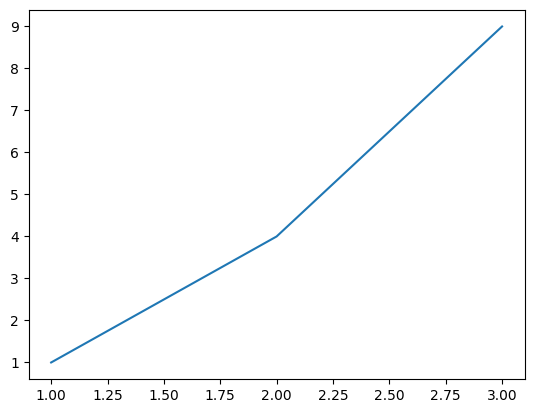

In [3]:
import matplotlib.pyplot as plt

plt.plot([1,2,3], [1,4,9])
plt.show()

In [4]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


In [6]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import sys
import os

sys.path.insert(0, os.path.abspath("../src"))

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [9]:
prices = pd.read_csv("../data/processed/prices.csv")
prices["date"] = pd.to_datetime(prices["date"])

prices.head()

,date,close,high,low,open,volume,ticker
0,2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,AAPL
1,2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,AAPL
2,2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,AAPL
3,2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,AAPL
4,2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,AAPL


In [10]:
prices = pd.read_csv("../data/processed/prices.csv")

In [11]:
prices.columns = [str(c).lower().strip() for c in prices.columns]

print(prices.columns)

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'ticker'], dtype='object')


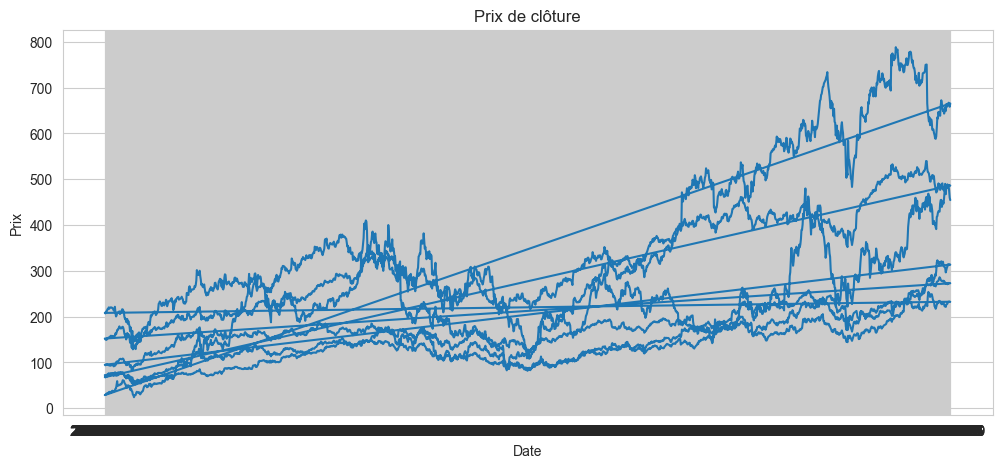

In [12]:
plt.figure(figsize=(12,5))
plt.plot(prices["date"], prices["close"])
plt.title("Prix de clôture")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

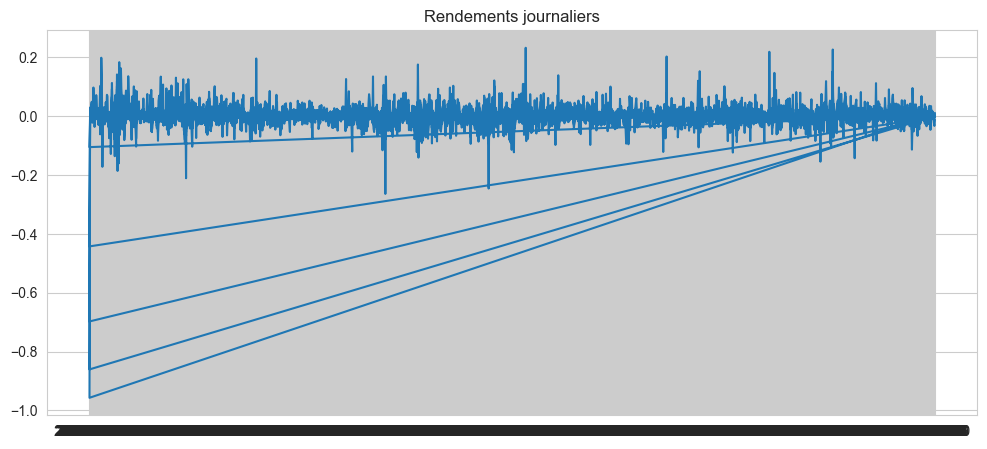

In [13]:
prices["return"] = prices["close"].pct_change()

plt.figure(figsize=(12,5))
plt.plot(prices["date"], prices["return"])
plt.title("Rendements journaliers")
plt.show()

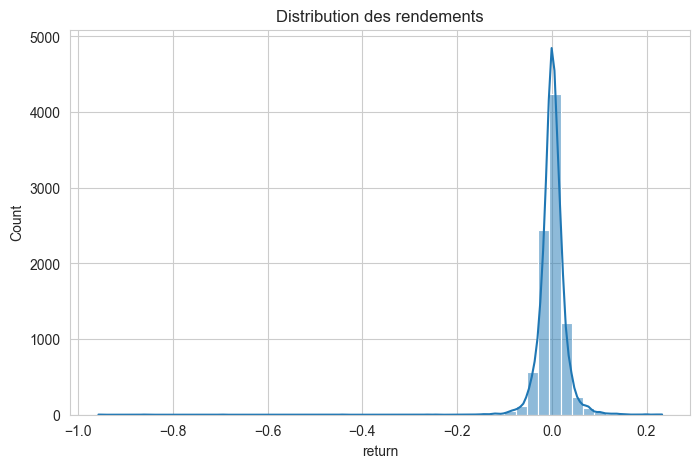

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(prices["return"].dropna(), bins=50, kde=True)
plt.title("Distribution des rendements")
plt.show()

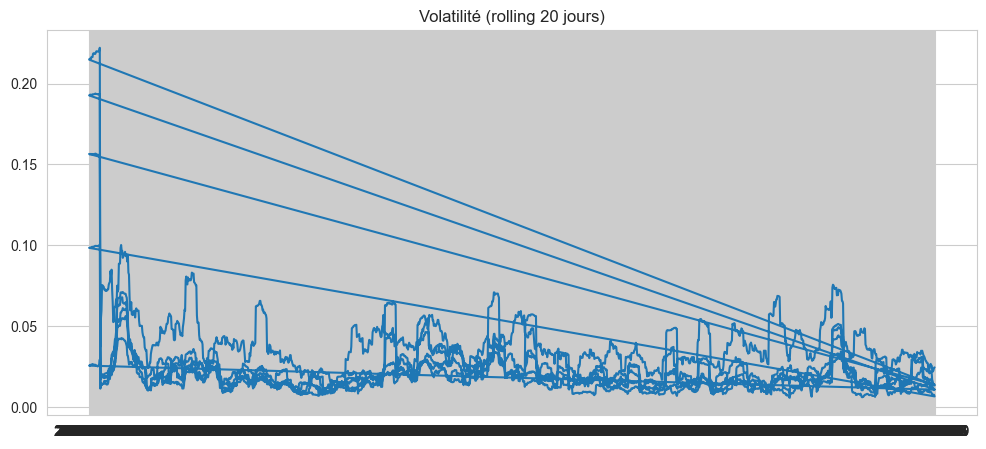

In [15]:
prices["volatility"] = prices["return"].rolling(20).std()

plt.figure(figsize=(12,5))
plt.plot(prices["date"], prices["volatility"])
plt.title("Volatilité (rolling 20 jours)")
plt.show()

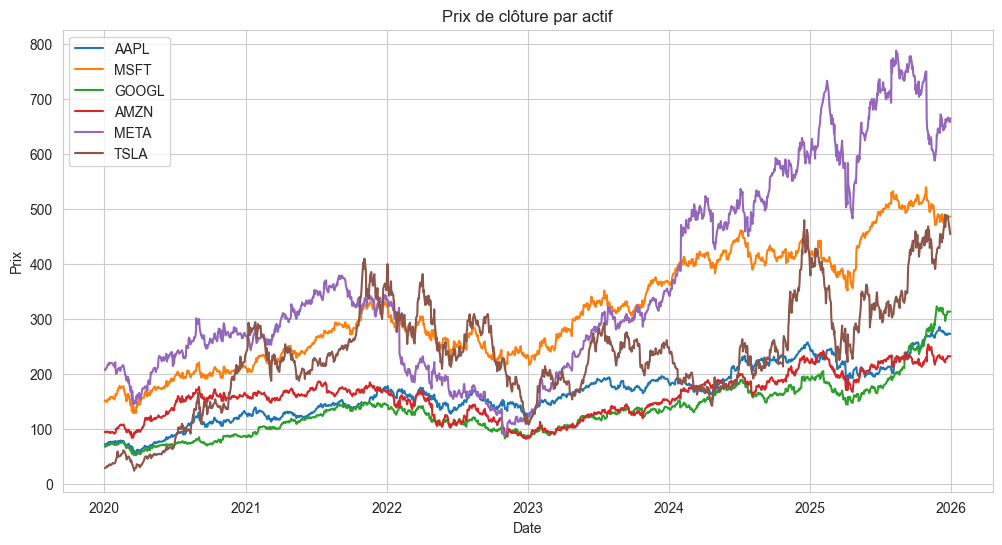

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/processed/prices.csv")
prices["date"] = pd.to_datetime(prices["date"])

plt.figure(figsize=(12,6))

for ticker in prices["ticker"].unique():
    df = prices[prices["ticker"] == ticker]
    plt.plot(df["date"], df["close"], label=ticker)

plt.title("Prix de clôture par actif")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.show()

In [17]:
daily_sentiment = pd.read_csv("../data/processed/daily_sentiment.csv")
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

In [18]:
daily_sentiment

,date,news_count,sentiment_mean,sentiment_std,sentiment_positive_ratio,sentiment_negative_ratio
0,2026-05-06,161,-0.037392,0.197953,0.080745,0.236025


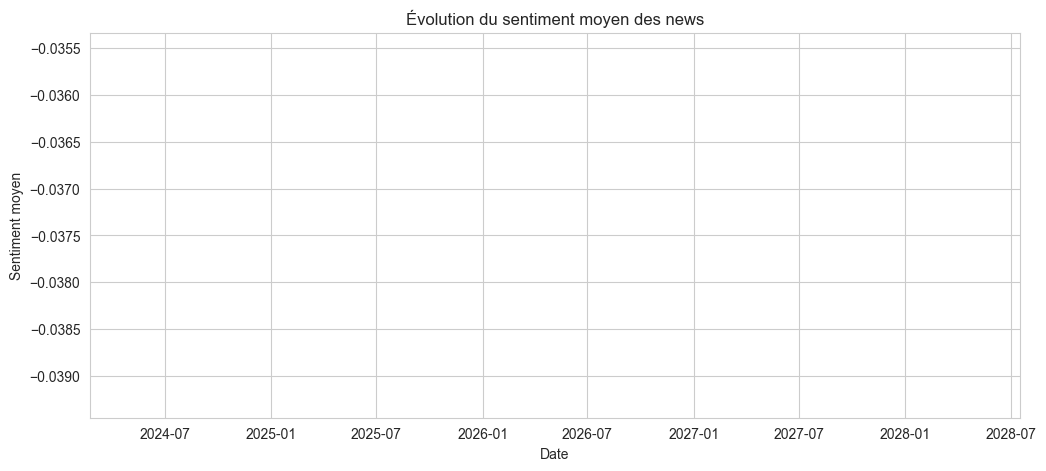

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

daily_sentiment = pd.read_csv("../data/processed/daily_sentiment.csv")
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

plt.figure(figsize=(12,5))
plt.plot(daily_sentiment["date"], daily_sentiment["sentiment_mean"])
plt.title("Évolution du sentiment moyen des news")
plt.xlabel("Date")
plt.ylabel("Sentiment moyen")
plt.grid(True)
plt.show()

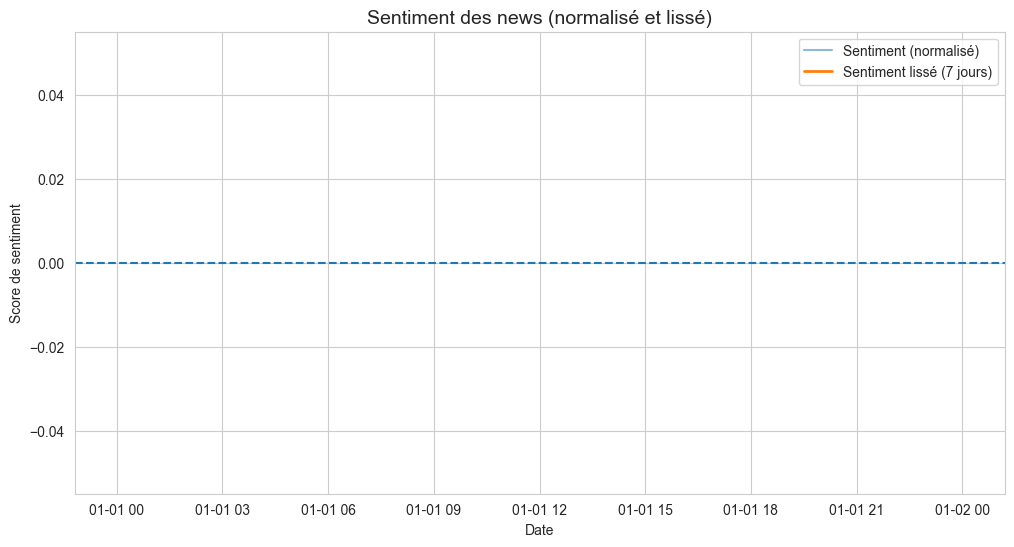

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

daily_sentiment = pd.read_csv("../data/processed/daily_sentiment.csv")
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

# Lissage (rolling mean)
daily_sentiment["sentiment_smooth"] = daily_sentiment["sentiment_mean"].rolling(7).mean()

# Normalisation (z-score)
daily_sentiment["sentiment_z"] = (
    (daily_sentiment["sentiment_mean"] - daily_sentiment["sentiment_mean"].mean()) /
    daily_sentiment["sentiment_mean"].std()
)

plt.figure(figsize=(12,6))

plt.plot(daily_sentiment["date"], daily_sentiment["sentiment_z"], label="Sentiment (normalisé)", alpha=0.5)
plt.plot(daily_sentiment["date"], daily_sentiment["sentiment_smooth"], label="Sentiment lissé (7 jours)", linewidth=2)

plt.axhline(0, linestyle="--")

plt.title("Sentiment des news (normalisé et lissé)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Score de sentiment")
plt.legend()
plt.grid(True)

plt.show()

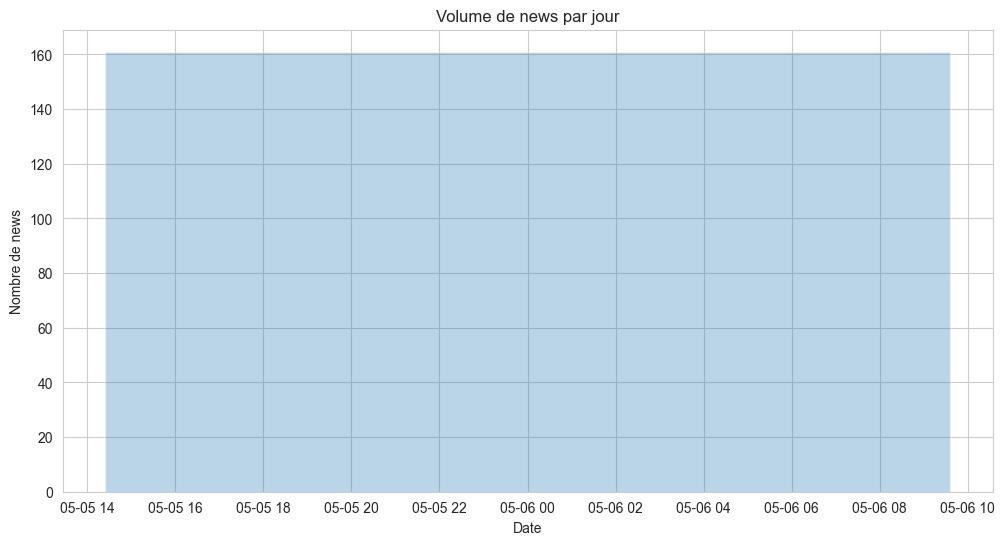

In [21]:
plt.figure(figsize=(12,6))

plt.bar(daily_sentiment["date"], daily_sentiment["news_count"], alpha=0.3)

plt.title("Volume de news par jour")
plt.xlabel("Date")
plt.ylabel("Nombre de news")
plt.grid(True)

plt.show()

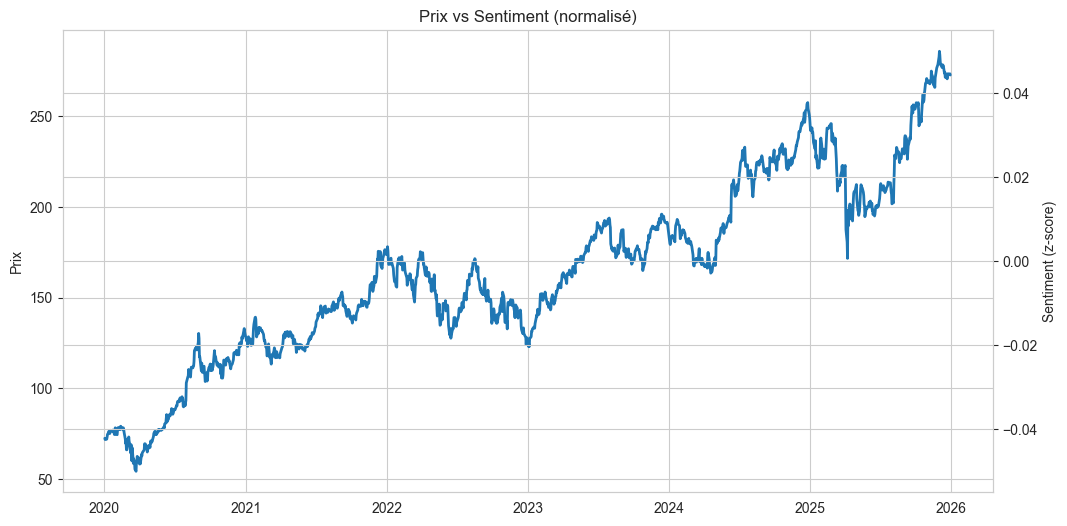

In [22]:
prices = pd.read_csv("../data/processed/prices.csv")
prices["date"] = pd.to_datetime(prices["date"])

# Exemple AAPL
aapl = prices[prices["ticker"] == "AAPL"].copy()

merged = aapl.merge(daily_sentiment, on="date", how="left")

# Normaliser sentiment
merged["sentiment_z"] = (
    (merged["sentiment_mean"] - merged["sentiment_mean"].mean()) /
    merged["sentiment_mean"].std()
)

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(merged["date"], merged["close"], label="Prix AAPL", linewidth=2)
ax1.set_ylabel("Prix")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["sentiment_z"], linestyle="--", alpha=0.7)
ax2.set_ylabel("Sentiment (z-score)")

plt.title("Prix vs Sentiment (normalisé)")
plt.grid(True)

plt.show()

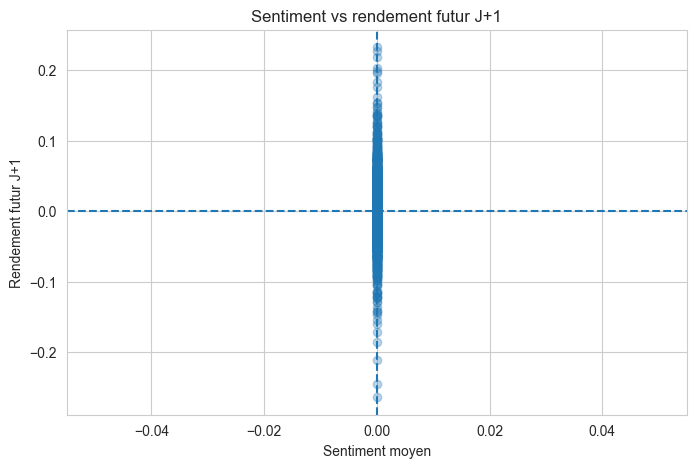

Corrélation : nan


In [23]:
# Corrélation sentiment vs rendement futur
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/processed/prices.csv")
daily_sentiment = pd.read_csv("../data/processed/daily_sentiment.csv")

prices["date"] = pd.to_datetime(prices["date"])
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

data = prices.merge(daily_sentiment, on="date", how="left")
data["sentiment_mean"] = data["sentiment_mean"].fillna(0)

data = data.sort_values(["ticker", "date"])
data["return"] = data.groupby("ticker")["close"].pct_change()
data["future_return"] = data.groupby("ticker")["return"].shift(-1)

plt.figure(figsize=(8,5))
plt.scatter(data["sentiment_mean"], data["future_return"], alpha=0.3)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Sentiment vs rendement futur J+1")
plt.xlabel("Sentiment moyen")
plt.ylabel("Rendement futur J+1")
plt.grid(True)
plt.show()

print("Corrélation :", data[["sentiment_mean", "future_return"]].corr().iloc[0,1])

/var/folders/8p/7lfjt3q55vq8rfxx7td30jfm0000gn/T/ipykernel_2496/1555581751.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sentiment_bucket")["future_return"]


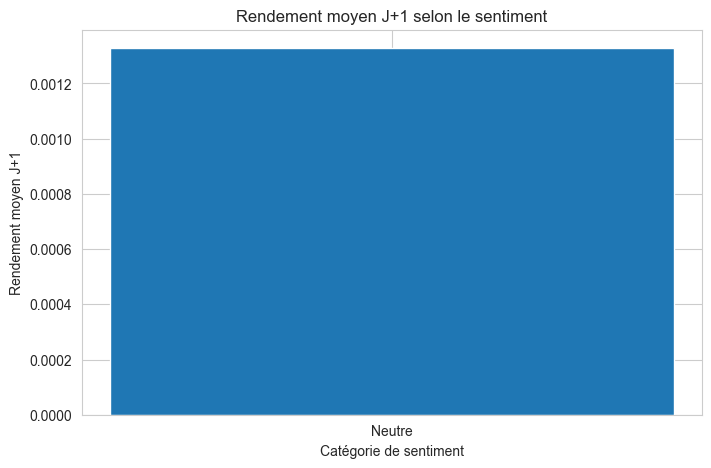

,sentiment_bucket,future_return
0,Négatif,NaN
1,Neutre,0.001328
2,Positif,NaN


In [24]:
# Corrélation sentiment vs rendement futur

data["sentiment_bucket"] = pd.cut(
    data["sentiment_mean"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["Négatif", "Neutre", "Positif"]
)

avg_returns = (
    data.groupby("sentiment_bucket")["future_return"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.bar(avg_returns["sentiment_bucket"], avg_returns["future_return"])
plt.title("Rendement moyen J+1 selon le sentiment")
plt.xlabel("Catégorie de sentiment")
plt.ylabel("Rendement moyen J+1")
plt.grid(True)
plt.show()

avg_returns

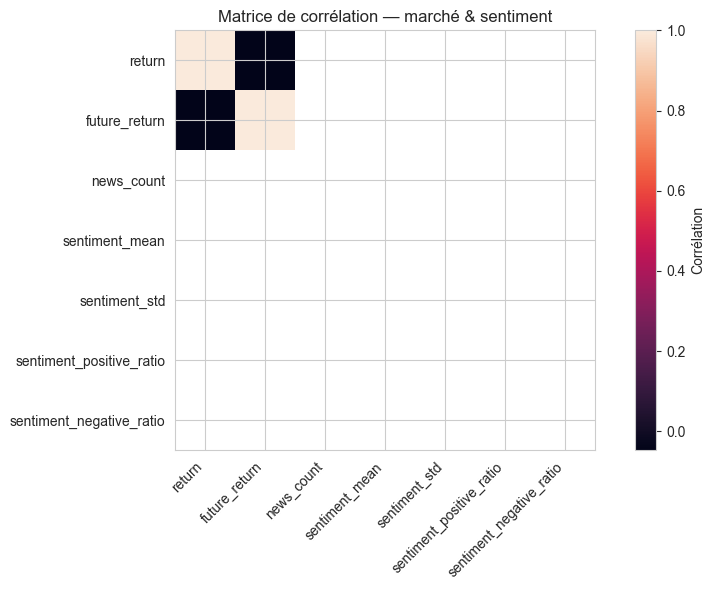

,return,future_return,news_count,sentiment_mean,sentiment_std,sentiment_positive_ratio,sentiment_negative_ratio
return,1.000000,-0.047332,NaN,NaN,NaN,NaN,NaN
future_return,-0.047332,1.000000,NaN,NaN,NaN,NaN,NaN
news_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_std,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_positive_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_negative_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Heatmap de corrélation des features
features_for_corr = [
    "return",
    "future_return",
    "news_count",
    "sentiment_mean",
    "sentiment_std",
    "sentiment_positive_ratio",
    "sentiment_negative_ratio"
]

corr = data[features_for_corr].corr()

plt.figure(figsize=(9,6))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Corrélation")
plt.title("Matrice de corrélation — marché & sentiment")
plt.tight_layout()
plt.show()

corr

In [26]:
import sys
!{sys.executable} -m pip install transformers torch

Defaulting to user installation because normal site-packages is not writeable
